In [1]:
import sys
import os 
PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

In [2]:
%pip install yfinance
from scripts.data_loader import get_stock_data


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install matplotlib
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[*********************100%***********************]  1 of 1 completed


Successfully downloaded 502 days of NVDA prices.
first 5 prices [48.14117432 47.54251099 47.97127533 49.069664   52.22390366]


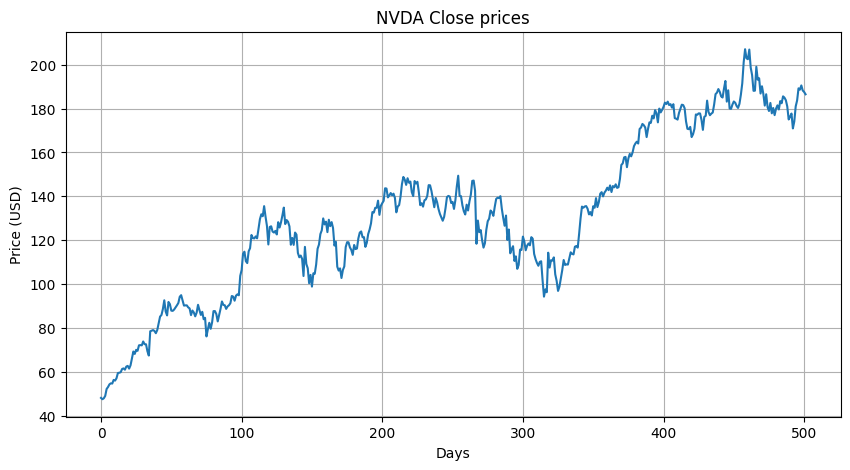

In [7]:
# define the parameters 
ticker = "NVDA" # Nvidia
start = "2024-01-01"
end = "2026-01-01"

# dowload the prices
prices = get_stock_data(ticker,start,end)

#check whether it worked
if prices is not None:
    print(f"Successfully downloaded {len(prices)} days of {ticker} prices.")
    print(f"first 5 prices {prices[:5]}")
    plt.figure(figsize=(10,5))
    plt.plot(prices)
    plt.title(f"{ticker} Close prices")
    plt.xlabel("Days")
    plt.ylabel("Price (USD)")
    plt.grid(True)
    plt.show()

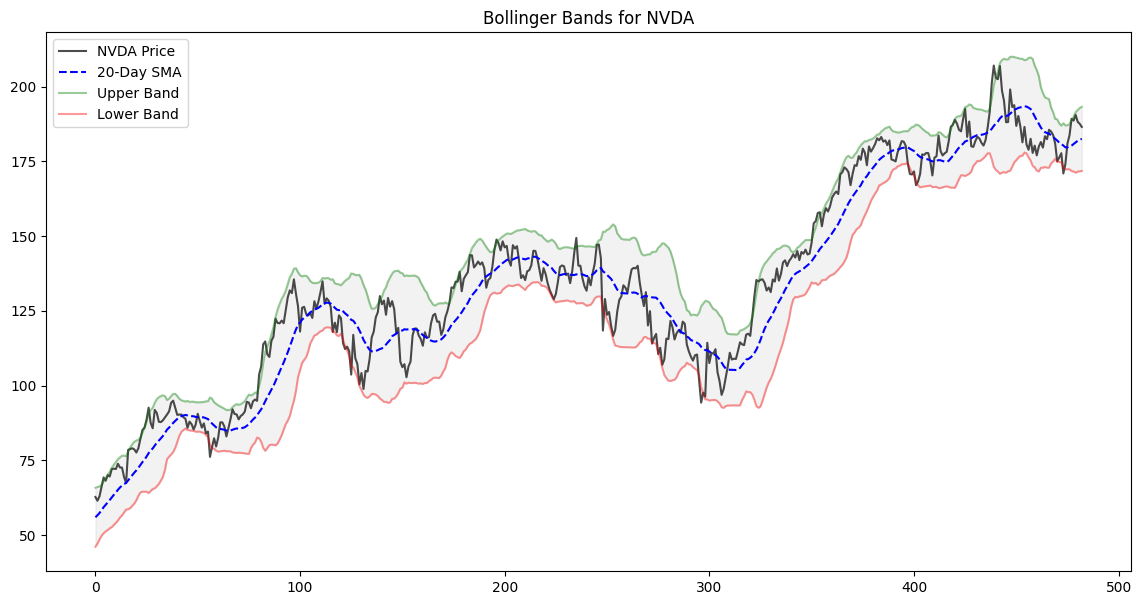

In [8]:
from scripts.indicators import calculate_bollinger_bands
upper,sma,lower = calculate_bollinger_bands(prices,window_size=20,num_std = 2)
plt.figure(figsize=(14,7))
#plot the actual price (skip the first 19 days to match the math output)
plt.plot(prices[19:], label='NVDA Price',color = 'black',alpha=0.7)

# plot the Middle SMA
plt.plot(sma, label ='20-Day SMA',color = 'blue',linestyle='--')

# plot the upper and lower bands
plt.plot(upper,label='Upper Band',color='green',alpha=0.4)
plt.plot(lower,label='Lower Band',color='red',alpha=0.4)

#fill the area between the bands (this is the 'volatility channel')
x = range(len(sma))
plt.fill_between(x,lower,upper,color='gray',alpha= 0.1)
plt.title(f"Bollinger Bands for {ticker}")
plt.legend()
plt.show()



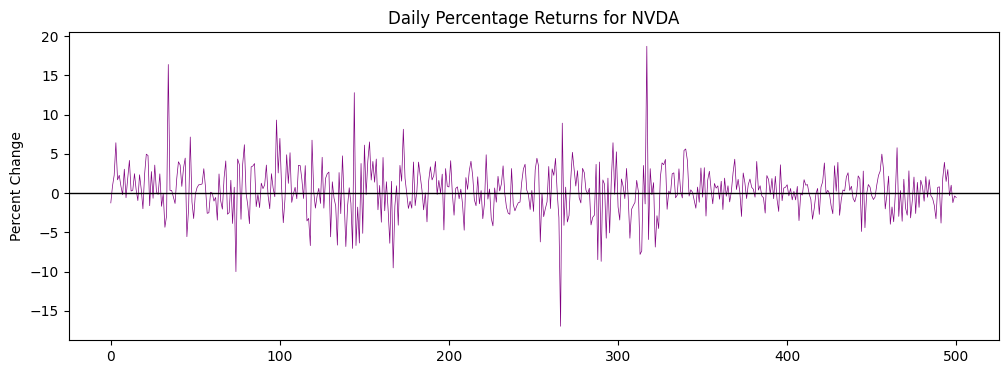

Max Single Day Gain: 18.72%
Max Single Day Loss: -16.97%


In [10]:
import numpy as np
from scripts.indicators import calculate_daily_return
#precentage change daily
daily_pct_change = calculate_daily_return(prices)
plt.figure(figsize=(12,4))
plt.plot(daily_pct_change,color='purple',lw=0.5)
plt.axhline(0,color ='black',lw=1) # the zero line
plt.title(f"Daily Percentage Returns for {ticker}")
plt.ylabel("Percent Change")
plt.show()

print(f"Max Single Day Gain: {np.max(daily_pct_change):.2f}%")
print(f"Max Single Day Loss: {np.min(daily_pct_change):.2f}%")